# Bayesian Logistic Regression Benchmark Setup

This notebook builds the real-dataset setup for Bayesian logistic regression with
parameterization `theta = [w, log(alpha)]`.

In [1]:
import jax
import jax.numpy as jnp

from datasets.bayesian_dataset import get_train_test_datasets
from experiments.bayesian_logistic_benchmark import (
    build_bayesian_logistic_setup,
    build_linear_potential_for_bayes_logistic,
    build_potential_for_bayes_logistic,
    classification_accuracy_from_particles,
)


/work/Sebas/miniconda3/envs/BV_Hamiltonian/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at grain/proto/execution_summary.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(


In [2]:
# Choose benchmark dataset
DATASET_NAME = "splice"  # titanic, covtype, german, diabetis, twonorm, ringnorm
test_ratio=0.2
seed=0
standardize=True

dataset = get_train_test_datasets(
    name=DATASET_NAME,
    data_path="data",
    test_ratio=test_ratio,
    seed=seed,
    standardize=standardize,
)
    


In [3]:

setup = build_bayesian_logistic_setup(
    dataset=dataset,
    alpha_prior_shape=1.0,
    alpha_prior_rate=0.01,
)

print("dataset:", setup.data.dataset_name)
print("X_train:", setup.X_train_jax.shape, "y_train:", setup.y_train_jax.shape)
print("X_test :", setup.X_test_jax.shape, "y_test :", setup.y_test_jax.shape)
print("n_features:", setup.data.n_features)


dataset: splice
X_train: (2393, 60) y_train: (2393,)
X_test : (598, 60) y_test : (598,)
n_features: 60


In [4]:
# Potential sanity check: theta has dimension d + 1 because theta = [w, log(alpha)]
d = setup.data.n_features
B = 16
key = jax.random.PRNGKey(0)
theta_batch = jax.random.normal(key, (B, d + 1))

U_vals = setup.potential_fn(theta_batch)
print("theta_batch shape:", theta_batch.shape)
print("U(theta) shape:", U_vals.shape)
print("first 3 values:", U_vals[:3])


theta_batch shape: (16, 61)
U(theta) shape: (16,)
first 3 values: [5390.95  4873.675 8655.668]


In [5]:
# Optional: quick predictive metric from random particles (just a smoke check)
acc = classification_accuracy_from_particles(
    theta_batch,
    setup.X_test_jax,
    setup.y_test_jax,
)
print("predictive accuracy from random particles:", float(acc))


predictive accuracy from random particles: 0.5518394708633423


In [6]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from parametric_model.parametric_model import ParametricModel
from geometry.G_matrix import G_matrix
from functionals.linear_funcitonal_class import LinearPotential
from functionals.internal_functional_class import InternalPotential
from functionals.functional import Potential
from flows.gradient_flow import run_gradient_flow
from flows.anderson_acceleration import anderson_method

In [7]:
# Setup parametric model
# theta dimension is d + 1 because theta = [w, log(alpha)]
problem_dim = d + 1
architecture = [problem_dim, 2, 64]
key = jax.random.PRNGKey(0)
parametric_map = 'node'
activation_fn = "tanh"
solver = "euler"
dt0 = 0.1
ref_density = 'gaussian'
scale_factor = 5e-2


In [8]:
parametric_model_gf = ParametricModel(
    parametric_map=parametric_map,
    architecture=architecture,
    key=key,
    activation_fn=activation_fn,
    time_dependent=True,
    solver=solver,
    dt0=dt0,
    ref_density=ref_density,
    scale_factor=scale_factor,
)
_,init_params= nnx.split(parametric_model_gf)

In [9]:
# Setup potential
linear = LinearPotential(potential_fn=setup.potential_fn, coeff=1.0)
internal = InternalPotential(
    functional="entropy",
    coeff=1.0,
    method="hutchinson",
    prob_dim=problem_dim,
)
potential = Potential(linear=linear, internal=internal, interaction=None)

In [10]:
G_mat_gf = G_matrix(parametric_model_gf)

In [11]:

key, kz = jax.random.split(key)
z_eval = parametric_model_gf.sampler(kz, 1024)


Gradient Flow Progress:   0%|          | 0/300 [00:00<?, ?it/s]2026-03-06 10:16:38.451318: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-06 10:16:39.181027: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-06 10:16:39.816364: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead

Iter 100: Energy = 3536.318604, Grad norm: 1.49e+02


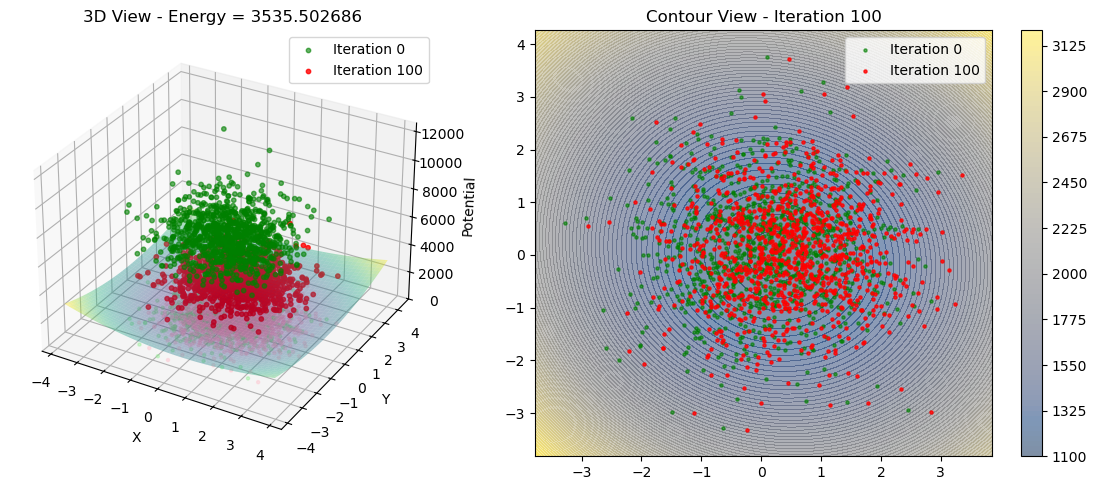

Gradient Flow Progress:  67%|██████▋   | 200/300 [16:30<07:36,  4.57s/it, Energy=3481.448730, Linear=3564.175537, Internal=-82.726761, Interaction=0.000e+00]

Iter 200: Energy = 3481.448730, Grad norm: 1.26e+02


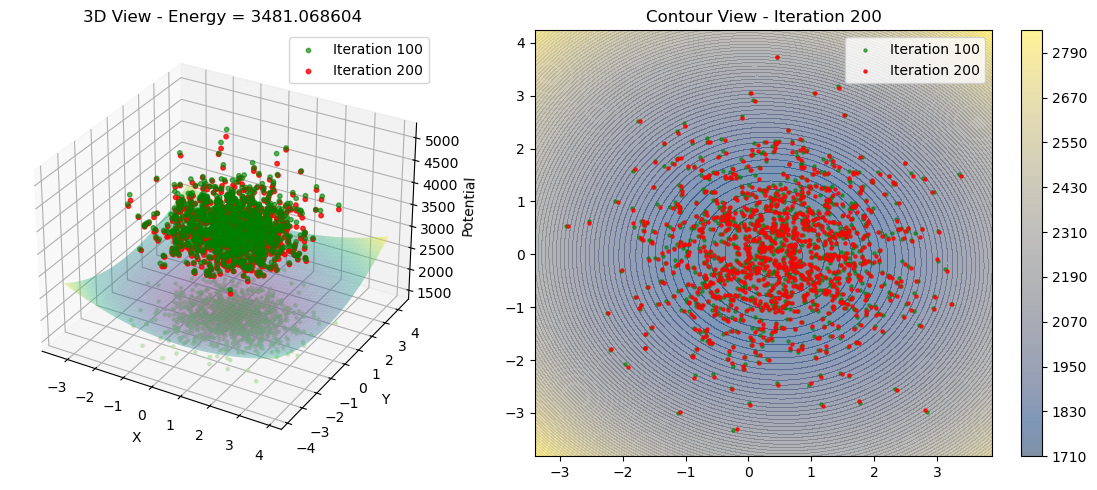

Gradient Flow Progress:  70%|███████   | 211/300 [17:16<07:17,  4.91s/it, Energy=3477.655762, Linear=3560.276123, Internal=-82.620483, Interaction=0.000e+00]


KeyboardInterrupt: 

In [12]:
results = run_gradient_flow(
    parametric_model=parametric_model_gf,
    z_samples=z_eval,
    G_mat=G_mat_gf,
    potential=potential,
    h=1e-3,
    solver="minres",
    N_samples=5_000,
    max_iterations=300,
    tolerance=1e-4,
    regularization=1e-2,
    progress_every=100,
    init_params=init_params
)

results["convergence_info"]


In [13]:
key,subkey = jax.random.split(key)
z_samples = parametric_model_gf.sampler(subkey, 4096)

In [14]:
samples = results['final_parametric_model'](z_samples)

2026-03-04 16:01:32.232444: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-04 16:01:33.050799: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-04 16:01:33.658931: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


In [15]:
acc = classification_accuracy_from_particles(
    samples,
    setup.X_test_jax,
    setup.y_test_jax,
)
print("predictive accuracy from random particles:", float(acc))


predictive accuracy from random particles: 0.8478260636329651


In [16]:
parametric_model_AA = nnx.clone(parametric_model_gf)
nnx.update(parametric_model_AA,init_params)

G_mat_AA = G_matrix(parametric_model_AA)


Starting Anderson-accelerated gradient flow
  n_iterations: 300
  step_size: 0.001
  memory_size: 8
  mixing_parameter: 1.25
  fixed_batch_steps: 1
  restart_steps: 50
------------------------------------------------------------


2026-03-04 16:01:36.151346: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-04 16:01:36.819539: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-04 16:01:37.505215: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-04 16:01:42.392882: W external/xla/xla/service/gpu/au

Iter    0 | Energy: 6.392586e+03 | Residual: 8.562711e-01 | 


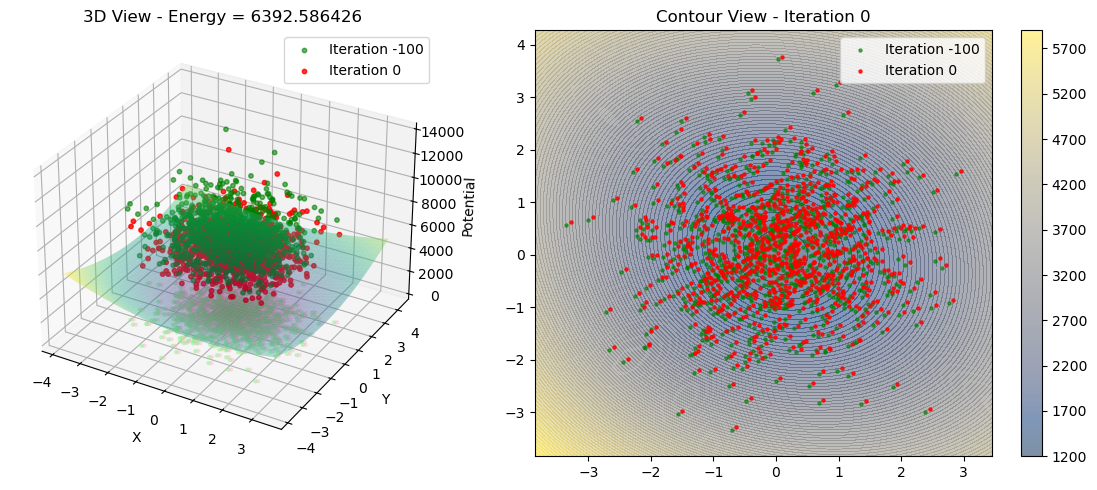

2026-03-04 16:02:08.293902: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-04 16:02:08.293953: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-04 16:02:08.293972: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


Iter    1 | Energy: 4.523026e+03 | Residual: 2.057751e-01 | 


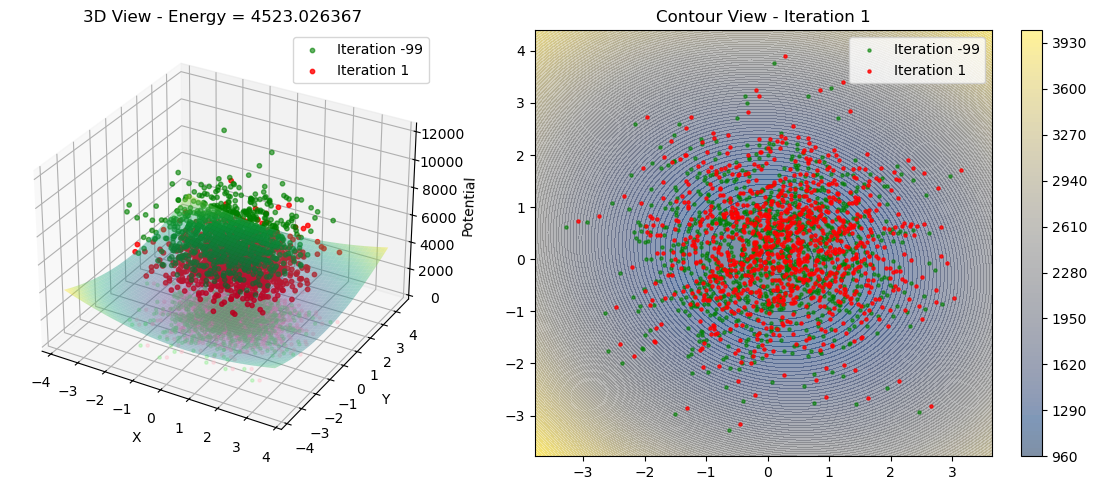

Iter    2 | Energy: 4.202836e+03 | Residual: 9.177221e-02 | 


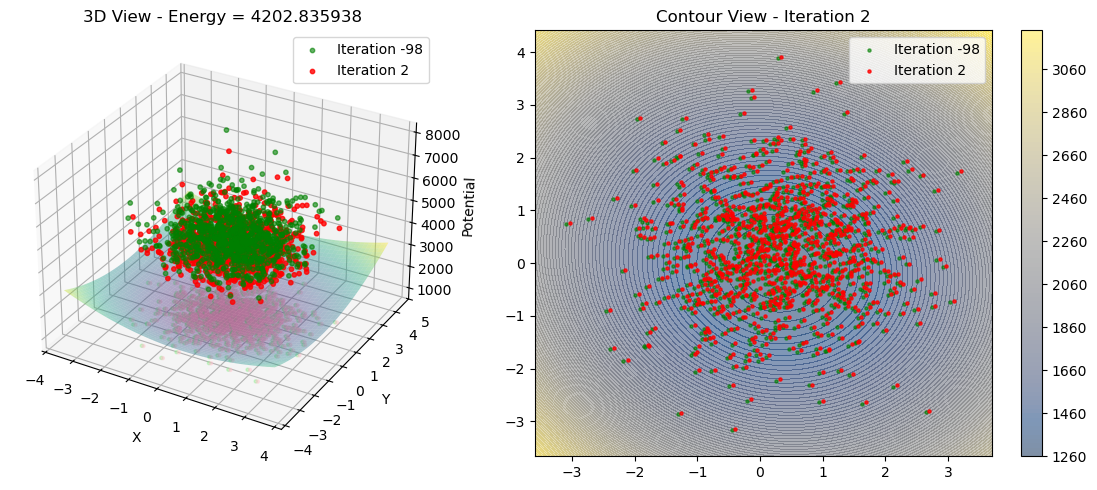

Iter    3 | Energy: 4.069205e+03 | Residual: 4.692356e-02 | 


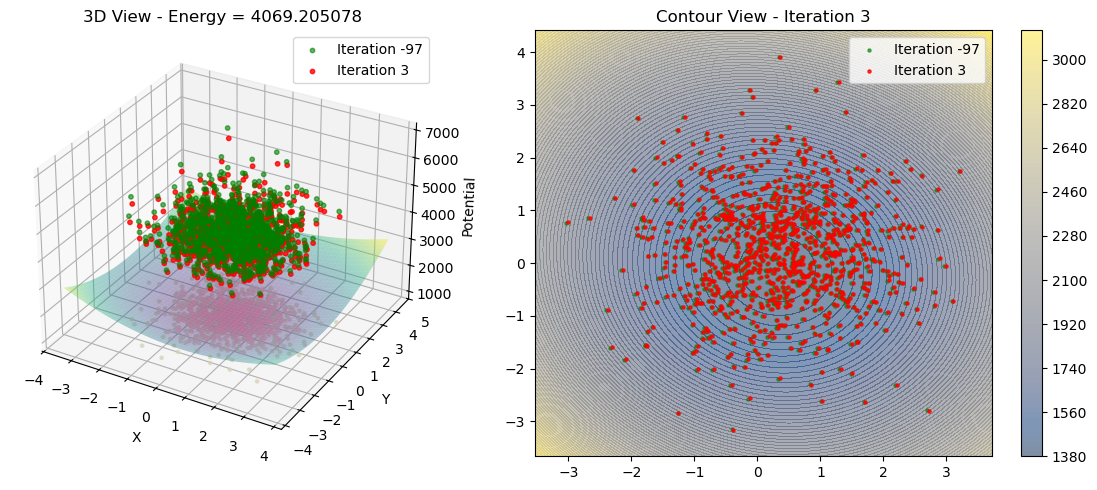

Iter    4 | Energy: 3.983436e+03 | Residual: 3.155039e-02 | 


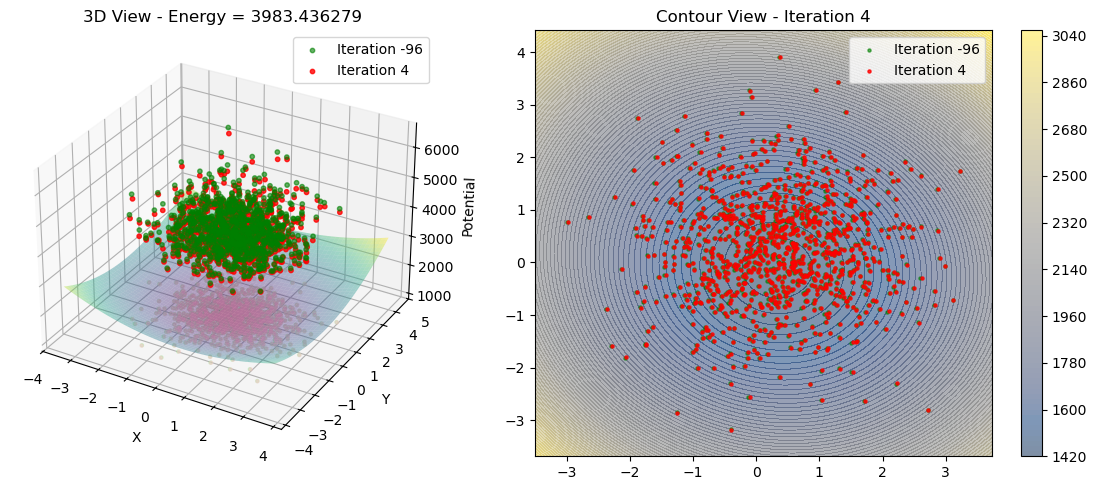

Iter  100 | Energy: 3.451651e+03 | Residual: 9.253764e-04 | 


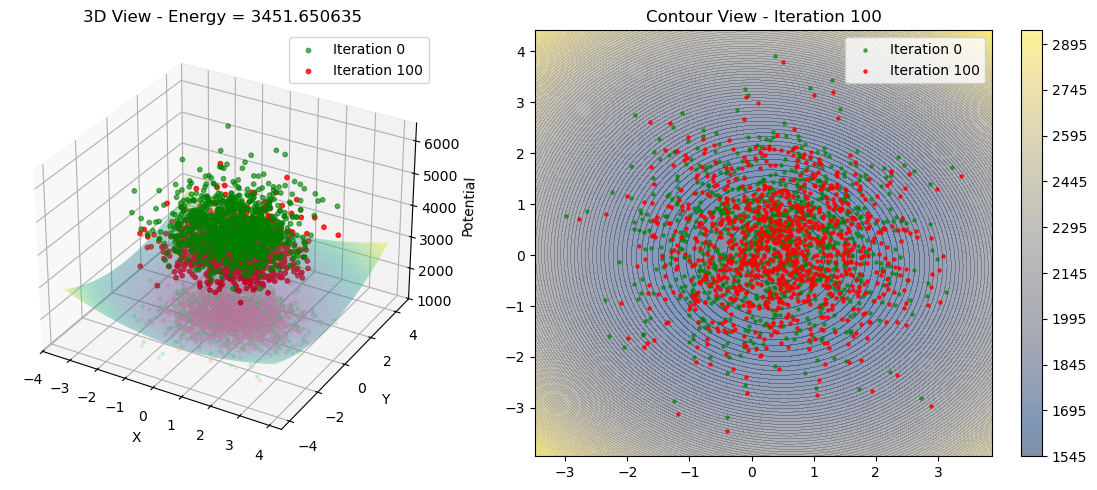

Iter  200 | Energy: 3.369031e+03 | Residual: 4.806399e-04 | 


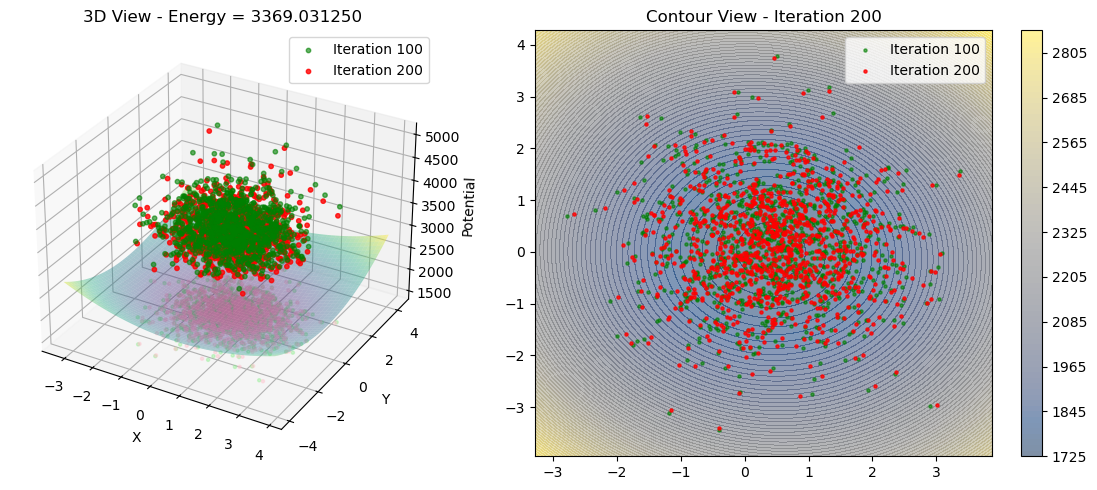

------------------------------------------------------------
Reached maximum iterations (300)
Final residual norm: 5.342608e-04
Final energy: 3.233082e+03


In [17]:
current_params_l2, history_l2 = anderson_method(
    parametric_model_AA, 
    batch_size=5000, 
    test_data_set=z_eval, 
    G_mat=G_mat_AA, 
    potential=potential,
    initial_params=init_params,
    solver="minres",
    n_iterations=300, 
    step_size=1e-3, 
    memory_size=8, 
    relaxation=1.25, 
    solver_tol= 1e-4,
    l2_reg_gamma=1e-2,
    plot_intermediate=True,
    plot_frequency=100,
    restart_steps=50,
    fixed_batch_steps=1,
    l2_inner_product=False,
)


In [18]:
samples_aa = history_l2['final_parametric_model'](z_samples)
acc = classification_accuracy_from_particles(
    samples_aa,
    setup.X_test_jax,
    setup.y_test_jax,
)
print("predictive accuracy from random particles:", float(acc))


predictive accuracy from random particles: 0.851170539855957


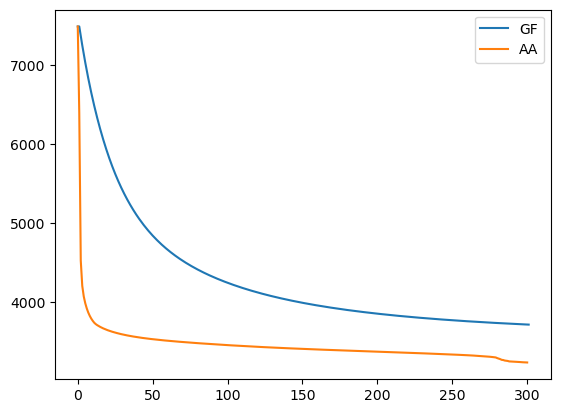

In [19]:

plt.plot(results['energy_history'][0:],label = 'GF')
plt.plot(history_l2['energies'][0:], label = 'AA')
plt.legend()
